# Fluspect leaf-parameter inversion from measured reflectance & transmittance

**Paper:** Vilfan, N., van der Tol, C., Verhoef, W. (2019).
*Estimating photosynthetic capacity from leaf reflectance and Chl fluorescence by coupling radiative transfer to a model for photosynthesis.*
New Phytologist 223(1): 487–500. DOI: [10.1111/nph.15782](https://doi.org/10.1111/nph.15782) (PMC6594113, CC BY; corrigendum 10.1111/nph.16401 not applied here).

**Scope (partial demonstration):** This notebook reproduces the **radiative-transfer half (stage 1) of the paper's Method 3** — per-leaf inversion of the Fluspect/PROSPECT model against measured leaf reflectance and transmittance — using the **authors' own pinned code** (`Christiaanvandertol/Fluspect` @ commit `d6c2fad6a0fc876f66cce51eeb12cff7d7c0bade`) and the repository's **example measured spectra**, run under **GNU Octave in Colab**.

**Not reproduced (data/script not public):** the full Vcmax retrieval (coupling Fluspect to the photosynthesis model, Methods 1–3), the paper's chamber and FluoWat measurement datasets, and the published RMSE numbers (<10 µmol m⁻² s⁻¹) — these require unpublished chamber/FluoWat gas-exchange/PAM data and an unpublished coupled-inversion script.

**AI-assisted adaptation notice / AI支援に関する注意:** The scientific model code executed here is the authors' original MATLAB code, unmodified, run under GNU Octave. The AI-assisted parts are: the Octave `lsqnonlin` replacement (bound-constrained nonlinear least squares, mathematically equivalent to the MATLAB Optimization Toolbox solver the authors call), Linux path/filename fixes, and all plotting. The authors did not provide this Colab implementation. The executed example and listed checks were validated, but untested behavior is not guaranteed.
/ **本ノーブックは著者自身の MATLAB コードを Octave でそのまま実行します。AI が補助したのは Octave 用ソルバー置換・パス修正・可視化のみです。**

**Execution status / 実行状況:** validated on a fresh Colab **CPU** runtime (see final outputs below). No GPU is used or needed (small dense linear algebra only).


## 1. Runtime selection / 実行環境の選択

**Select Runtime → Change runtime type → CPU** (standard CPU runtime is recommended and sufficient; there is no GPU-specific code path — the method is a small nonlinear least-squares fit over ~2,000 wavelengths).

Expected end-to-end time on CPU: roughly 5–10 minutes (apt installation of GNU Octave dominates). Total downloads: < 1 MB (author code + example spectra + optical parameter file).

**推奨ランタイムは CPU です。GPU は不要です（小規模な非線形最小二乗計算のみ）。**

The next cell just records the allocated hardware for the validation record.


In [ ]:
import platform, os, subprocess
print("Python:", platform.python_version())
print("CPUs:", os.cpu_count())
try:
    print(subprocess.run(["free", "-h"], capture_output=True, text=True).stdout.strip().splitlines()[1])
except Exception as e:
    print("free unavailable:", e)


Python: 3.13.15
CPUs: 2
Mem:            12Gi       896Mi       8.9Gi       2.1Mi       3.1Gi        11Gi


## 2. Setup — install GNU Octave / セットアップ: Octave のインストール

The authors' code is MATLAB. GNU Octave runs it unchanged except for `lsqnonlin` (MATLAB Optimization Toolbox), for which this notebook provides a documented replacement (Section 6). We install Octave and the `octave-optim` package (preferred bound-constrained least-squares solver), streaming output so an install failure is visible.

**MATLAB コードを動かすため GNU Octave をインストールします（失敗は表示されます）。**


In [ ]:
import subprocess, sys

def run(cmd, tail=4000):
    """Run a shell command on the Colab VM, streaming to a log, showing the tail."""
    log = "/content/setup_install.log"
    with open(log, "wb") as f:
        p = subprocess.run(cmd, shell=True, stdout=f, stderr=subprocess.STDOUT)
    with open(log, "r", errors="replace") as f:
        out = f.read()
    print(out[-tail:] if len(out) > tail else out)
    if p.returncode != 0:
        raise RuntimeError(f"Command failed ({p.returncode}): {cmd}")
    return p.returncode

run("apt-get update -qq")
run("DEBIAN_FRONTEND=noninteractive apt-get install -y -qq octave octave-optim")
print("apt install OK")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)



 up libsundials-nvecparallel-petsc6:amd64 (6.4.1+dfsg1-3build4) ...
Setting up pstoedit (4.00-1.1build2) ...
Setting up libsundials-sunlinsol3:amd64 (6.4.1+dfsg1-3build4) ...
Setting up octave (8.4.0-1build5) ...
Setting up octave-statistics-common (1.6.3-1ubuntu2) ...
Setting up octave-statistics (1.6.3-1ubuntu2) ...
Setting up octave-struct:amd64 (1.0.18-3build1) ...
Setting up octave-optim:amd64 (1.6.2-3build1) ...
Setting up libwww-perl (6.76-1ubuntu0.1) ...
Setting up liblwp-protocol-https-perl (6.13-1) ...
Setting up libxml-parser-perl (2.47-1ubuntu0.24.04.1) ...
Setting up libxml-sax-expat-perl (0.51-2) ...
update-perl-sax-parsers: Registering Perl SAX parser XML::SAX::Expat with priority 50...
update-perl-sax-parsers: Updating overall Perl SAX parser modules info file...
Replacing config file /etc/perl/XML/SAX/ParserDetails.ini with new version
Processing triggers for libgdk-pixbuf-2.0-0:amd64 (2.42.10+dfsg-3ubuntu3.3) ...
Processing triggers for install-info (7.1-3build2) ...


## 3. Verify Octave and the solver package / Octave とソルバーの確認

We verify the Octave version and that the `optim` package (providing `nonlin_residmin`, a bound-constrained nonlinear least-squares solver) loads. If the package is unavailable, the notebook's `lsqnonlin` replacement automatically falls back to a built-in Levenberg–Marquardt solver (Section 6).

**Octave のバージョンと optim パッケージの読み込みを確認します。**


In [ ]:
p = subprocess.run(
    ["octave", "--no-gui", "--quiet", "--eval",
     "disp(version); try, pkg load optim; disp('OPTIM_OK'); catch, disp('OPTIM_MISSING'); end"],
    capture_output=True, text=True, timeout=300)
print(p.stdout)
if p.returncode != 0:
    print("STDERR:", p.stderr[-2000:])
print("OPTIM_OK" in p.stdout and "optim package available (nonlin_residmin will be used)"
      or "optim package unavailable — Levenberg–Marquardt fallback will be used")


8.4.0
OPTIM_OK

optim package available (nonlin_residmin will be used)


## 4. Acquire the pinned author code and data (in Colab only) / ピン留めしたコミットからコードとデータを取得

All bytes are downloaded **inside this Colab VM** from the pinned commit
`d6c2fad6a0fc876f66cce51eeb12cff7d7c0bade` of `Christiaanvandertol/Fluspect` (the repository named by the paper's investigation; public, GPL as stated in the article text — no license file is present in the repository).

Integrity check: for every file we query the GitHub **git tree API once** for the pinned commit and verify the downloaded bytes' **git blob SHA-1** (`sha1("blob <size>\0" + bytes)`), rejecting truncated or mutated downloads. Rate-limit responses (HTTP 403/429) are retried with bounded waits.

**GitHub のピン留めコミットから生ファイルを取得し、git blob SHA-1 で完全性を検証します。**


In [ ]:
import hashlib, json, time, urllib.request, pathlib

REPO = "Christiaanvandertol/Fluspect"
COMMIT = "d6c2fad6a0fc876f66cce51eeb12cff7d7c0bade"
BASE = pathlib.Path("/content/fluspect")

WANTED = [
    # author code (executed unmodified under Octave)
    "Fluspect_retrievals.m", "COST_4Fluspect.m", "fluspect_B_CX.m",
    "define_bands.m", "define_constants.m",
    # example measured spectra + optical parameters (inputs, stay on the Colab VM)
    "data/measured/exampledata/wl.txt",
    "data/measured/exampledata/Reflectance.txt",
    "data/measured/exampledata/Transmittance.txt",
    "data/parameters/Optipar2021_ProspectPRO_CX.mat",
]

def github_json(url):
    for attempt in range(4):
        req = urllib.request.Request(url, headers={"Accept": "application/vnd.github+json",
                                                   "User-Agent": "colab-fluspect-repro"})
        with urllib.request.urlopen(req, timeout=60) as r:
            if r.status == 200:
                return json.load(r)
        time.sleep(5 * (attempt + 1))
    raise RuntimeError(f"GitHub API failed for {url}")

tree = github_json(f"https://api.github.com/repos/{REPO}/git/trees/{COMMIT}?recursive=1")
assert not tree.get("truncated"), "tree listing truncated"
blobs = {t["path"]: t for t in tree["tree"] if t["type"] == "blob"}
missing = [p for p in WANTED if p not in blobs]
assert not missing, f"paths absent at pinned commit: {missing}"

def blob_sha1(data):
    return hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()

for path in WANTED:
    dest = BASE / path
    dest.parent.mkdir(parents=True, exist_ok=True)
    url = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}/{path}"
    data = None
    for attempt in range(4):
        try:
            with urllib.request.urlopen(urllib.request.Request(url, headers={"User-Agent": "colab-fluspect-repro"}), timeout=120) as r:
                data = r.read()
            break
        except Exception as e:
            print(f"retry {attempt+1} for {path}: {e}")
            time.sleep(5 * (attempt + 1))
    assert data is not None, f"download failed: {path}"
    got, want = blob_sha1(data), blobs[path]["sha"]
    assert got == want, f"blob SHA mismatch for {path}: {got} != {want}"
    dest.write_bytes(data)
    print(f"OK  {path:60s} {len(data):>8d} B  sha1={got[:12]}…")

print("\nAll files verified against pinned commit", COMMIT[:12])


OK  Fluspect_retrievals.m                                            4531 B  sha1=ce918edb769d…
OK  COST_4Fluspect.m                                                 1550 B  sha1=375e246693e7…
OK  fluspect_B_CX.m                                                  9957 B  sha1=f0a06e4b9652…
OK  define_bands.m                                                   1152 B  sha1=a61479929437…


OK  define_constants.m                                               1065 B  sha1=db3d475fd4aa…
OK  data/measured/exampledata/wl.txt                                36567 B  sha1=f4eb468d5175…
OK  data/measured/exampledata/Reflectance.txt                      174231 B  sha1=f0184d2fd2c9…


OK  data/measured/exampledata/Transmittance.txt                    174231 B  sha1=6cdcb9889757…
OK  data/parameters/Optipar2021_ProspectPRO_CX.mat                  94368 B  sha1=e64b70aaef52…

All files verified against pinned commit d6c2fad6a0fc


## 5. Input preview — the example measured spectra / 入力データのプレビュー

The repository's default example inputs are leaf hyperspectral measurements (FluoWat-type leaf clip spectra, as described in the paper's Methods for the chamber dataset): `wl.txt` (wavelengths, one per row), `Reflectance.txt` and `Transmittance.txt` (one measured leaf per column). We load them, assert consistent dimensions, and plot all measured spectra before any fitting. These are the notebook's **only scientific inputs**; no weights are needed.

**測定反射率・透過率スペクトルを読み込み、フィッティング前に全列をプロットします。**


wavelengths: (2151,) 350–2500 nm
reflectance: (2151, 5)  transmittance: (2151, 5)
measured leaves (columns): 5


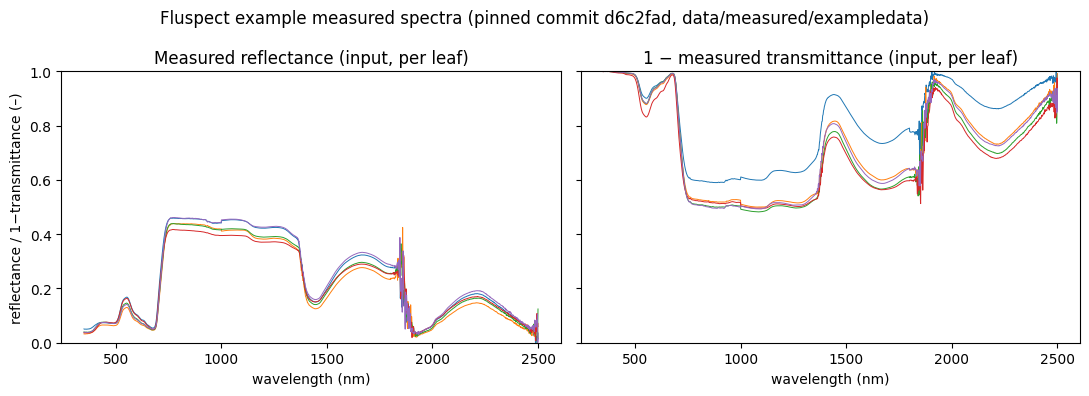

In [ ]:
import numpy as np, os
import matplotlib.pyplot as plt

os.makedirs("/content/out", exist_ok=True)
DATA = "/content/fluspect/data/measured/exampledata/"
wl = np.loadtxt(DATA + "wl.txt")
if wl.ndim > 1:
    wl = wl[:, 0]
R = np.loadtxt(DATA + "Reflectance.txt")
T = np.loadtxt(DATA + "Transmittance.txt")

print("wavelengths:", wl.shape, f"{wl.min():.0f}–{wl.max():.0f} nm")
print("reflectance:", R.shape, " transmittance:", T.shape)
assert R.shape == T.shape and R.shape[0] == len(wl)
n_leaves = R.shape[1]
print("measured leaves (columns):", n_leaves)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for j in range(n_leaves):
    axes[0].plot(wl, R[:, j], lw=0.7)
    axes[1].plot(wl, 1 - T[:, j], lw=0.7)
axes[0].set_title("Measured reflectance (input, per leaf)")
axes[1].set_title("1 − measured transmittance (input, per leaf)")
for ax in axes:
    ax.set_xlabel("wavelength (nm)"); ax.set_ylim(0, 1)
axes[0].set_ylabel("reflectance / 1−transmittance (–)")
fig.suptitle("Fluspect example measured spectra (pinned commit d6c2fad, data/measured/exampledata)")
plt.tight_layout()
import os
os.makedirs("/content/out", exist_ok=True)
plt.savefig("/content/out/measured_spectra.png", dpi=110)
plt.show()


## 6. The Octave driver and the documented `lsqnonlin` replacement / ドライバーとソルバー置換

We write three files (nothing in the authors' own code is edited):

1. **`driver.m`** — a compact replica of the relevant part of the authors' `master.m`: same example data, same initial leaf parameters (`Cab=28, Cdm=0.001, Cw=0.002, Cs=0.015, Cca=4, Cant=1, V2Z=0, N=1.5, fqe=0.01`), same include flags (`Cab, Cdm, Cw, Cs, Cca, N` fitted; `Cant, V2Z` fixed), `target=0` (fit R **and** T), `wlrange 400–2400 nm`, all leaf columns (`c = 1:end`), std = 0.03. Documented fixes: Linux path separators and the actual filename `Reflectance.txt` (the authors' `input_data.m` writes `reflectance.txt`, which fails on case-sensitive filesystems); CSV output via `dlmwrite` instead of `writetable`/`struct2table`.
2. **`lsqnonlin.m`** — an Octave replacement for MATLAB's `lsqnonlin(fun, x0, LB, UB)` with identical call signature: it uses `optim`'s bound-constrained `nonlin_residmin` when available, otherwise a built-in bounded Levenberg–Marquardt fallback. Residual vector, bounds (LB `[0, .001, 0, 0, 0, 0, 0, 1]`, UB `[100, .5, .4, .6, 30, 5, 3, 4]`) and initial values are exactly the authors'.
3. The authors' own `Fluspect_retrievals.m` then calls our `lsqnonlin` unchanged.

**著者コード `master.m` の該当部分を再現するドライバーと、MATLAB の `lsqnonlin` と同じ呼び出し規約を持つ置換ソルバーを作成します（著者コード自体は無変更）。**


In [ ]:
DRIVER = r'''% driver.m — minimal replica of the retrieval part of the authors' master.m
% (Christiaanvandertol/Fluspect @ d6c2fad). Documented adaptations:
% forward-slash paths, actual filename 'Reflectance.txt' (case), dlmwrite output.
measdir = 'data/measured/exampledata/';
wl          = load([measdir 'wl.txt']);
measured.refl  = load([measdir 'Reflectance.txt']);
measured.tran  = load([measdir 'Transmittance.txt']);
wl = wl(:,1);

load('data/parameters/Optipar2021_ProspectPRO_CX.mat');
[spectral] = define_bands;

measured.std = .03*ones(length(wl), size(measured.refl,2));

% initial parameters / include flags: exactly as in the authors' input_data.m
leafbio.Cab = 28;    leafbio.Cdm = 0.001; leafbio.Cw = 0.002;
leafbio.Cs  = 0.015; leafbio.Cca = 4;     leafbio.Cant = 1;
leafbio.V2Z = 0;     leafbio.N   = 1.5;   leafbio.fqe  = 0.01;
leafbio.Cp  = 0;     leafbio.Cbc = 0;
include.Cab = 1; include.Cdm = 1; include.Cw = 1; include.Cs = 1;
include.Cca = 1; include.Cant = 0; include.V2Z = 0; include.N = 1;
target = 0;              % 0: fit reflectance AND transmittance
wlrange.wlmin = 400; wlrange.wlmax = 2400;
c = 1:size(measured.refl,2);   % all measured leaves, as with the authors' c = -999

tic;
[er,params0,params1,spectral,reflF,tranF,leafopt,leafbio,leafopt_all,leafbio_all,optipar] = ...
    Fluspect_retrievals(leafbio,c,include,target,measured,wl,wlrange,optipar,spectral);
printf('retrieval wall time: %.1f s\n', toc);

if isfield(leafbio_all,'Cab') && numel(leafbio_all.Cab) > 1
  lbtab = [leafbio_all.Cab leafbio_all.Cdm leafbio_all.Cw leafbio_all.Cs ...
           leafbio_all.Cca leafbio_all.Cant leafbio_all.V2Z leafbio_all.N];
else
  lbtab = [leafbio.Cab leafbio.Cdm leafbio.Cw leafbio.Cs leafbio.Cca leafbio.Cant leafbio.V2Z leafbio.N];
end
csvwrite('leafbio_fitted.csv', lbtab);
csvwrite('rmse_per_leaf.csv', leafopt_all.rmse(:));
dlmwrite('FLUSPECT_reflectance.csv',   [spectral.wlP', leafopt_all.refl], 'delimiter', ',');
dlmwrite('FLUSPECT_transmittance.csv', [spectral.wlP', leafopt_all.tran], 'delimiter', ',');
dlmwrite('MEAS_reflectance.csv',       [wl, measured.refl], 'delimiter', ',');
dlmwrite('MEAS_transmittance.csv',     [wl, measured.tran], 'delimiter', ',');
printf('DRIVER_DONE\n');
'''

LSQ = r'''function [x, resnorm, residual] = lsqnonlin(fun, x0, lb, ub)
% Octave replacement for MATLAB Optimization Toolbox lsqnonlin(fun, x0, lb, ub).
% Prefers optim's bound-constrained nonlinear least squares (nonlin_residmin);
% falls back to a bounded Levenberg-Marquardt solver. Same call signature.
  have_optim = false;
  try
    if ~exist('nonlin_residmin', 'builtin') && ~exist('nonlin_residmin', 'file')
      pkg load optim;
    end
    have_optim = exist('nonlin_residmin', 'builtin') || exist('nonlin_residmin', 'file');
  catch
    have_optim = false;
  end
  if have_optim
    s = optimset('lbound', lb, 'ubound', ub, 'MaxIter', 500, 'TolFun', 1e-10, 'TolX', 1e-10);
    x = nonlin_residmin(fun, x0, s);
  else
    x = lm_bounded(fun, x0, lb, ub);
  end
  residual = fun(x);
  resnorm = residual' * residual;
end

function x = lm_bounded(f, x0, lb, ub)
% Bound-projected Levenberg-Marquardt with central-difference Jacobian.
  x = min(max(x0, lb), ub);
  r = f(x); F = r' * r; mu = 1e-3;
  for it = 1:300
    J = zeros(numel(r), numel(x));
    for i = 1:numel(x)
      h = 1e-6 * max(1, abs(x(i)));
      xp = x; xm = x;
      xp(i) = min(xp(i) + h, ub(i)); xm(i) = max(xm(i) - h, lb(i));
      hh = xp(i) - xm(i); if hh == 0, hh = h; end
      J(:, i) = (f(xp) - f(xm)) / hh;
    end
    g = J' * r; A = J' * J; accepted = false;
    for inner = 1:50
      dx = -(A + mu * diag(max(diag(A), 1e-12))) \g;
      xn = min(max(x + dx, lb), ub);
      rn = f(xn); Fn = rn' * rn;
      if Fn < F
        x = xn; r = rn; F = Fn; mu = max(mu / 3, 1e-12); accepted = true; break;
      else
        mu = mu * 5;
      end
    end
    if ~accepted, break; end
    if (F - Fn) < 1e-14 * max(1, F), break; end
  end
end
'''

import pathlib
BASE = pathlib.Path("/content/fluspect")
(BASE / "driver.m").write_text(DRIVER)
(BASE / "lsqnonlin.m").write_text(LSQ)
print("wrote", BASE / "driver.m", "and", BASE / "lsqnonlin.m")


wrote /content/fluspect/driver.m and /content/fluspect/lsqnonlin.m


## 7. Run the authors' retrieval under Octave / 反転計算の実行

We run `driver` with Octave (streamed output). The author function `Fluspect_retrievals.m` fits, for every measured leaf, the 6 free Fluspect/PROSPECT parameters against both measured R and T over 400–2400 nm, calling the authors' `COST_4Fluspect.m` and `fluspect_B_CX.m` unchanged.

Before the fit, one runtime unknown is resolved here: whether the optical parameter file `Optipar2021_ProspectPRO_CX.mat` is a MATLAB v7 file (Octave loads it natively). If Octave cannot load it, we convert it with SciPy and clearly report the conversion (a v7.3/HDF5 file would stop with an explicit error rather than silently substitute anything).

**`Optipar` .mat の読み込み可否を確認し（v7 ならそのまま、非対応なら明示的にエラー）、Octave でドライバーを実行します。**


In [ ]:
import subprocess, pathlib, os
os.makedirs("/content/out", exist_ok=True)

def octave_eval(code):
    p = subprocess.run(["octave", "--no-gui", "--quiet", "--eval", code],
                       capture_output=True, text=True, timeout=1800)
    return p

# --- resolve the .mat-format runtime unknown explicitly ---
p = octave_eval("try, load('/content/fluspect/data/parameters/Optipar2021_ProspectPRO_CX.mat'); "
                "disp('MAT_OK'); catch, disp('MAT_FAIL'); end")
print(p.stdout.strip())
if "MAT_FAIL" in p.stdout:
    try:
        import scipy.io as sio
        m = sio.loadmat("/content/fluspect/data/parameters/Optipar2021_ProspectPRO_CX.mat",
                        squeeze_me=True, struct_as_record=False)
        m = {k: v for k, v in m.items() if not k.startswith("__")}
        sio.savemat("/content/fluspect/data/parameters/Optipar_converted_v5.mat", m)
        # point the driver at the converted file
        drv = pathlib.Path("/content/fluspect/driver.m")
        drv.write_text(drv.read_text().replace("Optipar2021_ProspectPRO_CX.mat", "Optipar_converted_v5.mat"))
        print("Converted .mat to v5 via SciPy; driver redirected. (Documented adaptation.)")
    except Exception as e:
        raise RuntimeError(
            "Optipar .mat could not be loaded by Octave nor converted (possible MATLAB v7.3/HDF5). "
            f"Stopping explicitly rather than substituting parameters. Original error: {e}")

# --- run the retrieval (authors' code, unmodified) ---
import time
t0 = time.time()
with open("/content/out/octave_run.log", "wb") as f:
    pr = subprocess.run('cd /content/fluspect && octave --no-gui --quiet --eval "driver"',
                        shell=True, stdout=f, stderr=subprocess.STDOUT, timeout=3600)
print(pr.stdout if pr.stdout else "")
with open("/content/out/octave_run.log") as f:
    log = f.read()
print(log[-6000:])
print(f"exit={pr.returncode}, wall={time.time()-t0:.1f} s")
assert pr.returncode == 0 and "DRIVER_DONE" in log, "Octave retrieval failed — see log above"


MAT_OK



    /usr/share/octave/packages/statistics-1.6.3/PKG_ADD at line 15 column 3
    load_packages_and_dependencies at line 56 column 5
    load_packages at line 53 column 3
    pkg at line 639 column 7
    lsqnonlin at line 8 column 7
    Fluspect_retrievals at line 51 column 20
    driver at line 27 column 91

    /usr/share/octave/packages/statistics-1.6.3/PKG_ADD at line 15 column 3
    load_packages_and_dependencies at line 56 column 5
    load_packages at line 53 column 3
    pkg at line 639 column 7
    lsqnonlin at line 8 column 7
    Fluspect_retrievals at line 51 column 20
    driver at line 27 column 91

    /usr/share/octave/packages/statistics-1.6.3/PKG_ADD at line 15 column 3
    load_packages_and_dependencies at line 56 column 5
    load_packages at line 53 column 3
    pkg at line 639 column 7
    lsqnonlin at line 8 column 7
    Fluspect_retrievals at line 51 column 20
    driver at line 27 column 91

    /usr/share/octave/packages/statistics-1.6.3/PKG_ADD at line 15 colum

## 8. Results — fitted leaf parameters and model–measurement fit / 結果

`Fluspect_retrievals` returned fitted `leafbio` values (per measured leaf) and the modelled R/T spectra. We tabulate the fitted parameters and RMSE per leaf, export a CSV, and plot measured vs fitted reflectance and 1−transmittance for the first two leaves (the graphs below are generated here for this notebook; they are not author figures).

**フィッティングされた葉パラメータと RMSE を表にし、測定値とモデルの適合をプロットします（このノーブック独自の図であり、論文の図ではありません）。**


,leaf,Cab,Cdm,Cw,Cs,Cca,Cant,V2Z,N,"RMSE(R,T)/std"
0,1,38.1171,0.0133,0.0173,0.1479,8.8876,1.0,0.0,1.9063,0.7402
1,2,43.8589,0.0069,0.0135,0.1378,10.8752,1.0,0.0,1.3950,0.5053
2,3,44.4801,0.0050,0.0116,0.1208,10.5337,1.0,0.0,1.3600,0.5023
3,4,29.4936,0.0068,0.0095,0.2415,6.4585,1.0,0.0,1.3212,0.5839
4,5,44.8676,0.0032,0.0129,0.0655,10.8397,1.0,0.0,1.4921,0.4419


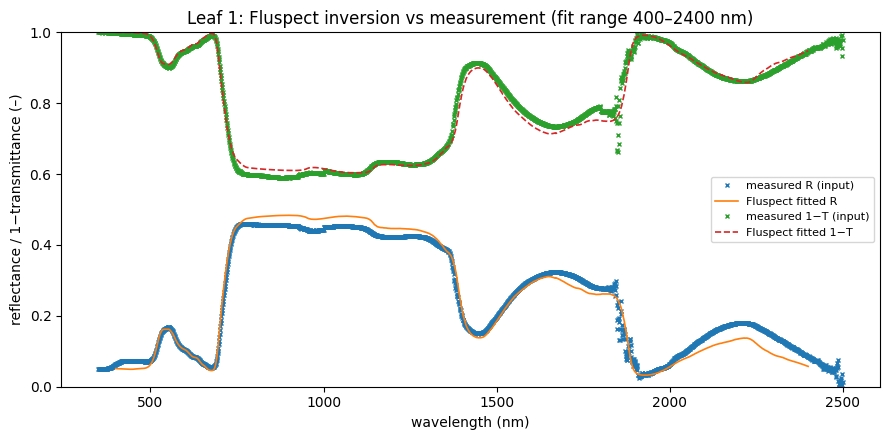

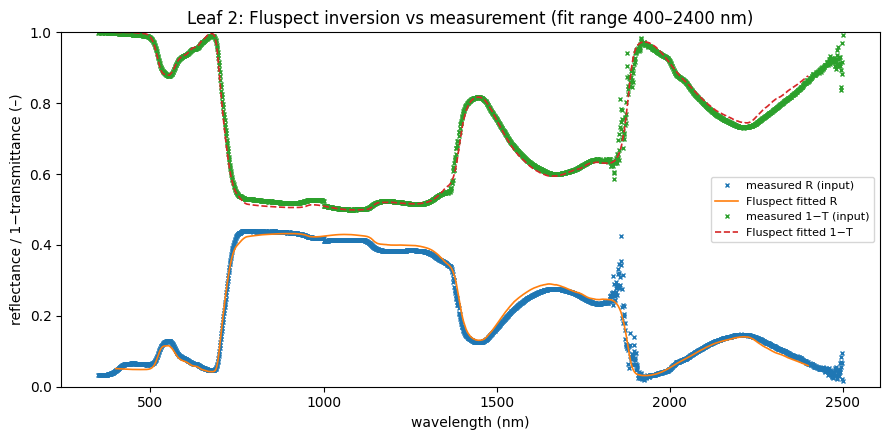

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

OUT = "/content/fluspect/"
names = ["Cab", "Cdm", "Cw", "Cs", "Cca", "Cant", "V2Z", "N"]
units = ["µg/cm²", "g/cm²", "cm", "–", "µg/cm²", "µg/cm²", "0–3", "–"]
tab = pd.DataFrame(np.loadtxt(OUT + "leafbio_fitted.csv", delimiter=","), columns=names)
tab.insert(0, "leaf", range(1, len(tab) + 1))
tab["RMSE(R,T)/std"] = np.loadtxt(OUT + "rmse_per_leaf.csv", delimiter=",")
try:
    display(tab.round(4))
except NameError:
    print(tab.round(4).to_string(index=False))
tab.round(6).to_csv("/content/out/fitted_leafbio.csv", index=False)

wlM = np.loadtxt(OUT + "MEAS_reflectance.csv", delimiter=",")[:, 0]
Rm  = np.loadtxt(OUT + "MEAS_reflectance.csv", delimiter=",")[:, 1:]
Tm  = np.loadtxt(OUT + "MEAS_transmittance.csv", delimiter=",")[:, 1:]
wlp = np.loadtxt(OUT + "FLUSPECT_reflectance.csv", delimiter=",")[:, 0]
Rf  = np.loadtxt(OUT + "FLUSPECT_reflectance.csv", delimiter=",")[:, 1:]
Tf  = np.loadtxt(OUT + "FLUSPECT_transmittance.csv", delimiter=",")[:, 1:]

for j in range(min(2, Rm.shape[1])):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(wlM, Rm[:, j], "x", ms=2.5, label="measured R (input)")
    ax.plot(wlp, Rf[:, j], "-", lw=1.2, label="Fluspect fitted R")
    ax.plot(wlM, 1 - Tm[:, j], "x", ms=2.5, label="measured 1−T (input)")
    ax.plot(wlp, 1 - Tf[:, j], "--", lw=1.2, label="Fluspect fitted 1−T")
    ax.set_xlabel("wavelength (nm)"); ax.set_ylabel("reflectance / 1−transmittance (–)")
    ax.set_ylim(0, 1); ax.legend(fontsize=8)
    ax.set_title(f"Leaf {j+1}: Fluspect inversion vs measurement (fit range 400–2400 nm)")
    plt.tight_layout()
    plt.savefig(f"/content/out/fit_leaf{j+1}.png", dpi=110)
    plt.show()


## 9. Interpretation, limitations, references / 解釈・限界・参考文献

**What was reproduced:** the authors' pinned Fluspect code (`d6c2fad`) inverting per-leaf structural/biochemical PROSPECT parameters (Cab, Cdm, Cw, Cs, Cca, N; Cant and xanthophyll status V2Z fixed) from the repository's example measured leaf reflectance and transmittance — stage 1 of the paper's Method 3 spectra-based retrieval chain. Plausibility check: fitted values must stay within the authors' bounds, and fitted spectra should follow the measured curves inside the 400–2400 nm fit range with a per-wavelength RMSE around the assumed measurement noise (std = 0.03), as designed by `COST_4Fluspect`.

**What was NOT reproduced (and why):** the paper's headline Vcmax results. The chamber (LI-6400 + Mini-PAM + FieldSpec) and FluoWat datasets have no public archive, and no script for the coupled Fluspect + photosynthesis-model inversion (the paper's Eqns 4–11) was published — this is a recorded material gap, not a code failure. The 2020 corrigendum (10.1111/nph.16401) was not assessed.

**Documented adaptations / 明示的な変更点:** MATLAB → Octave; `lsqnonlin` → bound-constrained `nonlin_residmin` (or LM fallback) with identical residuals/bounds/initial values; Linux path case fix (`Reflectance.txt`); CSV output instead of `writetable`. The model code `fluspect_B_CX.m`, `COST_4Fluspect.m`, `Fluspect_retrievals.m` and `define_bands.m` are the authors', unmodified.

**References:** Vilfan et al. 2019, New Phytologist 223(1):487–500, DOI 10.1111/nph.15782 (CC BY); code: https://github.com/Christiaanvandertol/Fluspect @ `d6c2fad6a0fc876f66cce51eeb12cff7d7c0bade`; SCOPE: https://github.com/Christiaanvandertol/SCOPE.
